## Variable Importance

In this notebook we compare three methods of assessing the importance of input variables (abundance measurements on biomolecules) to some the predicted output (e.g. virus vs non-virus). The three methods are:

1. **SHAP** - SHapley Additive exPlanations
2. **Integrated Gradients** - Integrated Gradients
3. **ANOVA p-values**

In [440]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW

from models.multi_mlp import simple_FC, JointMLP
from featimportance.igrads import integrated_grads
from featimportance.comparison import overlap_sets
from featimportance.plot_helpers import igrad_beeswarm_plot, make_igrad_plot_df

import numpy as np
import pandas as pd
import copy
import datetime

from sklearn.metrics import roc_curve, auc, confusion_matrix

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import shap

## Load ICL-104

In [98]:
proData = pd.read_csv('~/Documents/Data/example_omicsdata/multi-omics-from-share/ICL104_Pep_Prot_Lipid_Metab/ICL104_proteins_luke.csv')
lipData = pd.read_excel("/Volumes/Data_Harmony/DHS_Omics/ICL04/ICL104_lipids_aligned_for_stats.xlsx")
metabData = pd.read_excel("/Volumes/Data_Harmony/DHS_Omics/ICL04/OMICS_ICL104_Metabolomics_YMK.xlsx")
metabData = metabData.drop(columns=['KEGG', 'CAS', 'PubChem'])

fmeta = pd.read_csv('~/Documents/Data/example_omicsdata/multi-omics-from-share/ICL104_Pep_Prot_Lipid_Metab/ICL104_fmeta.csv')

In [99]:
# some samples missing from some datasets.
lipData.shape, metabData.shape, proData.shape

((250, 61), (138, 61), (2853, 61))

In [100]:
# filter all rows in fmeta where any of SampleID_proteomics, SampleID_proteomics, SampleID_metab are NA
fmeta = fmeta[~fmeta[['SampleID_proteomics', 'SampleID_lipidpos', 'SampleID_metab']].isna().any(axis=1)]
fmeta['Virus_y'] = fmeta.Virus.replace({'Cal[0-9]*': 'Cal'}, regex=True)
y = fmeta.Virus_y

In [101]:
# make the "LIPID" column in lipData the index
lipData = lipData.set_index('Name')
metabData = metabData.set_index('Metabolite')
proData = proData.set_index('Protein')

# replace zeros with NA
lipData[lipData == 0] = np.nan
metabData[metabData == 0] = np.nan

# log2 transform the data and column-wise median center
lipData = np.log2(lipData)
metabData = np.log2(metabData)
# proData = np.log2(proData) # don't if already log2

lipData = lipData - lipData.median(axis=0)
metabData = metabData - metabData.median(axis=0)
proData = proData - proData.median(axis=0)

# [0, 1] normalize all the data
lipData = (lipData - np.min(lipData)) / (np.max(lipData) - np.min(lipData))
metabData = (metabData - np.min(metabData)) / (np.max(metabData) - np.min(metabData))
proData = (proData - np.min(proData)) / (np.max(proData) - np.min(proData))

In [102]:
# columns are nicely aligned
y = pd.Series(['Cal' if 'Cal04' in el else 'Mock' for el in lipData.columns])

In [103]:
# drop indices with all null values
lip_inds = (lipData.isnull() == False).sum(axis = 1) > 0
metab_inds = (metabData.isnull() == False).sum(axis = 1) > 0
pro_inds = (proData.isnull() == False).sum(axis = 1) > 0

lipData = lipData[lip_inds]
metabData = metabData[metab_inds]
proData = proData[pro_inds]

# impute the datasets with the row means
lipData = lipData.apply(lambda row: row.fillna(row.mean()), axis=1)
metabData = metabData.apply(lambda row: row.fillna(row.mean()), axis=1)
proData = proData.apply(lambda row: row.fillna(row.mean()), axis=1)


In [13]:
# Use this if our column names are aligned with f_meta, otherwise make sure to manually check that they align
# lipData = lipData.loc[:,lipData.columns.isin(fmeta['SampleID_lipidpos'])]
# metabData = metabData.loc[:,metabData.columns.isin(fmeta['SampleID_metab'])]
# proData = proData.loc[:,proData.columns.isin(fmeta['SampleID_proteomics'])]

In [104]:
np.random.seed(1565)
cal_inds = np.random.choice(np.where(y == 'Cal')[0], int(np.sum(y == 'Cal') * 0.2))
mock_inds = np.random.choice(np.where(y == 'Mock')[0], int(np.sum(y == 'Mock') * 0.2))
test_inds = np.concatenate([cal_inds, mock_inds])

train_inds = np.isin(np.arange(y.shape[0]), test_inds) == False

train_lip = lipData.iloc[:,train_inds]
train_pro = proData.iloc[:,train_inds]
train_metab = metabData.iloc[:,train_inds]

test_lip = lipData.iloc[:, test_inds]
test_pro = proData.iloc[:, test_inds]
test_metab = metabData.iloc[:, test_inds]

ytrain = y.iloc[train_inds]
ytest = y.iloc[test_inds]

### Construct and Train the Model

In [105]:
# three view-specific encoders with the appropriate input size:

# the last hidden size must be the same since we are averaging
last_hidden_size = 64

lip_marg = simple_FC(input_size=train_lip.shape[0], hidden_sizes=[128, last_hidden_size], prediction_dim=y.nunique())
metab_marg = simple_FC(input_size=train_metab.shape[0], hidden_sizes=[64, last_hidden_size], prediction_dim=y.nunique())
pro_marg = simple_FC(input_size=train_pro.shape[0], hidden_sizes=[256, last_hidden_size], prediction_dim=y.nunique())

# joint model
joint_model = JointMLP(marginal_models=[lip_marg, metab_marg, pro_marg], hidden_dim=128)

# define optimizer
optimizer = AdamW(joint_model.parameters(), lr=1e-4)

In [106]:
# turn data into tensors
lip_tensor = torch.tensor(train_lip.T.values, dtype=torch.float32)
pro_tensor = torch.tensor(train_pro.T.values, dtype=torch.float32)
metab_tensor = torch.tensor(train_metab.T.values, dtype=torch.float32)

y_gt = ytrain.astype('category').cat.codes
y_gt = torch.tensor(y_gt.values, dtype=torch.int64)

for i in range(1250):

    views = [lip_tensor, metab_tensor, pro_tensor]
    
    # randomly drop an index with low probability
    if np.random.rand() < 0.1:
        idx = np.random.randint(0, len(views))
        views = [v if i != idx else None for i, v in enumerate(views)]

    # get the predictions and distribution of the joint model, and the predictions and distributions of the marginal models
    yhat, h, yhats, hiddens = joint_model(views)

    # pass the predictions and distributions to the loss function and update parameters
    loss = joint_model.loss(y_gt, yhat, yhats)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(joint_model.parameters(), 2.0)
    optimizer.step()

    print(f'Epoch {i+1} loss: {loss.item():.3f}')

Epoch 1 loss: 0.706
Epoch 2 loss: 0.711
Epoch 3 loss: 0.710
Epoch 4 loss: 0.693
Epoch 5 loss: 0.702
Epoch 6 loss: 0.704
Epoch 7 loss: 0.700
Epoch 8 loss: 0.704
Epoch 9 loss: 0.702
Epoch 10 loss: 0.693
Epoch 11 loss: 0.693
Epoch 12 loss: 0.698
Epoch 13 loss: 0.693
Epoch 14 loss: 0.693
Epoch 15 loss: 0.701
Epoch 16 loss: 0.698
Epoch 17 loss: 0.523
Epoch 18 loss: 0.701
Epoch 19 loss: 0.695
Epoch 20 loss: 0.692
Epoch 21 loss: 0.698
Epoch 22 loss: 0.692
Epoch 23 loss: 0.521
Epoch 24 loss: 0.698
Epoch 25 loss: 0.702
Epoch 26 loss: 0.691
Epoch 27 loss: 0.524
Epoch 28 loss: 0.691
Epoch 29 loss: 0.690
Epoch 30 loss: 0.694
Epoch 31 loss: 0.691
Epoch 32 loss: 0.688
Epoch 33 loss: 0.700
Epoch 34 loss: 0.694
Epoch 35 loss: 0.695
Epoch 36 loss: 0.694
Epoch 37 loss: 0.692
Epoch 38 loss: 0.696
Epoch 39 loss: 0.690
Epoch 40 loss: 0.693
Epoch 41 loss: 0.692
Epoch 42 loss: 0.686
Epoch 43 loss: 0.691
Epoch 44 loss: 0.692
Epoch 45 loss: 0.695
Epoch 46 loss: 0.693
Epoch 47 loss: 0.691
Epoch 48 loss: 0.701
E

In [107]:
# example prediction
joint_model.eval()

ytest_gt = ytest.astype('category').cat.codes

liptest_tensor = torch.tensor(test_lip.T.values, dtype=torch.float32)
protest_tensor = torch.tensor(test_pro.T.values, dtype=torch.float32)
metabtest_tensor = torch.tensor(test_metab.T.values, dtype=torch.float32)

with torch.inference_mode():
    yhat, hiddens, yhats, dists = joint_model([liptest_tensor, metabtest_tensor, protest_tensor])

ypred = yhat.argmax(dim=1).numpy()

(ypred == ytest_gt.to_numpy()).mean()

1.0

### Shapley Values

Shapley values are a method of assigning importance to input variables.  The particular flavor of the Shapley values framework is a version of DEEPLift (Shrikumar, Greenside, and Kundaj, 2017), implemented in the SHAP packages (https://shap.readthedocs.io/en/latest/index.html) and modified with findings from (Lee and Lundberg, 2017).

In [207]:
# need to wrap the model in this class to get around some issues with the SHAP package
class JointMLPWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x1, x2, x3):
        yhat, _, _, _ = self.model([x1, x2, x3])
        return yhat
    
joint_model_wrp = JointMLPWrapper(joint_model)

In [208]:
# make the explainer object
explainer = shap.DeepExplainer(joint_model_wrp, views)

In [156]:
# compute the shapley values
shap_values = explainer.shap_values([liptest_tensor, metabtest_tensor, protest_tensor], check_additivity=False)

In [ ]:
# absolute sum values and sorted scores
abs_lip_shap = np.abs(shap_lip).sum(axis = 0)
abs_pro_shap = np.abs(shap_pro).sum(axis = 0)
abs_metab_shap = np.abs(shap_metab).sum(axis = 0)

sorted_lip_shap = sorted(abs_lip_shap, reverse = True)
sorted_pro_shap = sorted(abs_pro_shap, reverse = True)
sorted_metab_shap = sorted(abs_metab_shap, reverse = True)

# shap output dataframes
lipids_shap = pd.DataFrame({
    "Lipids":test_lip.iloc[(-abs_lip_shap).argsort(), :].index,
    "Lipid_Scores": sorted_lip_shap
})

proteins_shap = pd.DataFrame({
    "Proteins": test_pro.iloc[(-abs_pro_shap).argsort(), :].index,
    "Protein_Scores": sorted_pro_shap
})

metabolites_shap = pd.DataFrame({
    "Metabolites": test_metab.iloc[(-abs_metab_shap).argsort(), :].index,
    "Metabolite_Scores": sorted_metab_shap
})

lip_shap_scores_df = pd.DataFrame(shap_lip.T)
lip_shap_scores_df.index = test_lip.index
lip_shap_scores_df.columns = test_lip.columns

pro_shap_scores_df = pd.DataFrame(shap_pro.T)
pro_shap_scores_df.index = test_pro.index
pro_shap_scores_df.columns = test_pro.columns

metab_shap_scores_df = pd.DataFrame(shap_metab.T)
metab_shap_scores_df.index = test_metab.index
metab_shap_scores_df.columns = test_metab.columns

lipids_shap_out = lipids_shap.merge(lip_shap_scores_df, how = 'left', left_on = 'Lipids', right_on = "Name")
proteins_shap_out = proteins_shap.merge(pro_shap_scores_df, how = 'left', left_on = 'Proteins', right_on = "Protein")
metabolites_shap_out = metabolites_shap.merge(metab_shap_scores_df, how = 'left', left_on = 'Metabolites', right_on = "Metabolite")

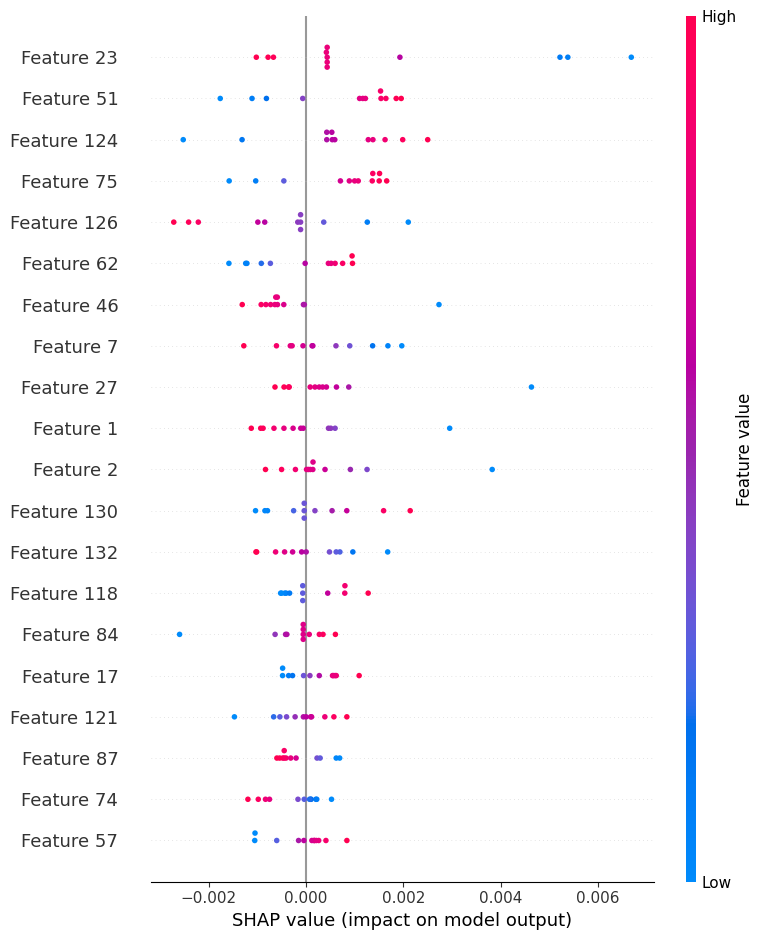

In [211]:
# index 0 is for the positive class
shap_lip = shap_values[0][0]
shap_metab = shap_values[0][1]
shap_pro = shap_values[0][2]

shap.summary_plot(shap_metab, metabtest_tensor)

# Integrated Gradients

Integrated gradients overcome the problem of non-sensitivity of gradients methods, see https://arxiv.org/pdf/1703.01365.pdf for an explanation.  

As described in the paper, we start at some 'non-informative' baseline, and move linearly towards our actual input, taking the gradient at each step and accumulating.  At the end we divide by the number of steps to get the average gradient, which approximates an integral.  This is the integrated gradient and the magnitude of each score can be seen as the strength of attribute, with the sign denoting the effect of the variable on the outcome.

We'll compare these to SHAP values, which are a more general approach to the same problem.

In [48]:
liptest_pos = torch.clone(liptest_tensor[ytest_gt.to_numpy() == 1])
protest_pos = torch.clone(protest_tensor[ytest_gt.to_numpy() == 1])
metabtest_pos = torch.clone(metabtest_tensor[ytest_gt.to_numpy() == 1])

In [49]:
# baseline is normal noise with mean and std from the data
# vary these to see if we get different results...
# scree plot
# lip_baseline = torch.randn_like(liptest_pos)*liptest_pos.std().numpy() + liptest_pos.mean().numpy()
# pro_baseline = torch.randn_like(protest_pos)*protest_pos.std().numpy() + protest_pos.mean().numpy()
# metab_baseline = torch.randn_like(metabtest_pos)*metabtest_pos.std().numpy() + metabtest_pos.mean().numpy()

lip_baseline = -torch.rand_like(liptest_pos)/2# *2*liptest_pos.std().numpy() + liptest_pos.mean().numpy()
pro_baseline = -torch.rand_like(protest_pos)/2# *2*protest_pos.std().numpy() + protest_pos.mean().numpy()
metab_baseline = -torch.rand_like(metabtest_pos)/2# *2*metabtest_pos.std().numpy() + metabtest_pos.mean().numpy()

# shuffle values of lip_baseline
lip_baseline = lip_baseline[:,torch.randperm(lip_baseline.shape[1])]
pro_baseline = pro_baseline[:,torch.randperm(pro_baseline.shape[1])]
metab_baseline = metab_baseline[:,torch.randperm(metab_baseline.shape[1])]


In [50]:
joint_model.eval()

lip_igrad_scores, metab_int_scores, pro_int_scores = integrated_grads(
    [liptest_pos, metabtest_pos, protest_pos], 
    [lip_baseline, metab_baseline, pro_baseline], 
    joint_model, n_steps = 100, class_idx = 0 # regrettably, 0 represents the 'Virus' condition here, no I'm not going to fix it.
)

In [51]:
top_lip = (-lip_int_scores.abs().sum(axis = 0)).argsort()[:10]
top_pro = (-pro_int_scores.abs().sum(axis = 0)).argsort()[:10]
top_metab = (-metab_int_scores.abs().sum(axis = 0)).argsort()[:10]

(
test_lip.iloc[top_lip.numpy(), :].index,
test_pro.iloc[top_pro.numpy(), :].index,
test_metab.iloc[top_metab.numpy(), :].index
)

(Index(['Cer(d18:0/24:0)', 'TG(54:3)', 'GalCer(d18:2/16:0)', 'PC(20:1/0:0)_B',
        'PC(12:0/18:2)', 'TG(54:4)', 'PC(O-18:0/20:4);PC(O-16:0/22:4)',
        'PC(0:0/20:4)', 'PC(14:0/14:0);PC(12:0/16:0)', 'DG(18:0/0:0/18:0)'],
       dtype='object', name='Name'),
 Index(['H1N1_CA04_NP', 'H1N1_CA04_M1', 'TSP1_HUMAN', 'TSP2_HUMAN',
        'H1N1_CA04_NS1', 'BGH3_HUMAN', 'SYCC_HUMAN', 'ITB4_HUMAN',
        'SPIT2_HUMAN', 'NMI_HUMAN'],
       dtype='object', name='Protein'),
 Index(['Unknown 066', 'putrescine', 'Unknown 056', 'L-glutamine',
        'Unknown 047', 'D-ribose-5-phosphate', 'glyceric acid',
        '3-phosphoglyceric acid', 'hypotaurine', 'L-methionine'],
       dtype='object', name='Metabolite'))

In [65]:
abs_lip_igrads = lip_int_scores.abs().sum(axis = 0).numpy()
abs_pro_igrads = pro_int_scores.abs().sum(axis = 0).numpy()
abs_metab_igrads = metab_int_scores.abs().sum(axis = 0).numpy()

sorted_lip_igrads = sorted(abs_lip_igrads, reverse = True)
sorted_pro_igrads = sorted(abs_pro_igrads, reverse = True)
sorted_metab_igrads = sorted(abs_metab_igrads, reverse = True)

In [261]:
# Output dataframes
lipids_igrad = pd.DataFrame({
    "Lipids":test_lip.iloc[(-abs_lip_igrads).argsort(), :].index,
    "Lipid_Scores": sorted_lip_igrads
})

proteins_igrad = pd.DataFrame({
    "Proteins": test_pro.iloc[(-abs_pro_igrads).argsort(), :].index,
    "Protein_Scores": sorted_pro_igrads
})

metabolites_igrad = pd.DataFrame({
    "Metabolites": test_metab.iloc[(-abs_metab_igrads).argsort(), :].index,
    "Metabolite_Scores": sorted_metab_igrads
})

lip_igrad_scores_df = pd.DataFrame(lip_int_scores.T)
lip_igrad_scores_df.index = test_lip.index
lip_igrad_scores_df.columns = test_lip.columns[ytest_gt.to_numpy() == 0]

pro_igrad_scores_df = pd.DataFrame(pro_int_scores.T)
pro_igrad_scores_df.index = test_pro.index
pro_igrad_scores_df.columns = test_pro.columns[ytest_gt.to_numpy() == 0]

metab_igrad_scores_df = pd.DataFrame(metab_int_scores.T)
metab_igrad_scores_df.index = test_metab.index
metab_igrad_scores_df.columns = test_metab.columns[ytest_gt.to_numpy() == 0]

# left join lipids_out to lip int scores "Lipids" = "Name"
lipids_igrad_out = lipids_igrad.merge(lip_igrad_scores_df, how = 'left', left_on = 'Lipids', right_on = "Name")
# left join proteins_out to pro int scores "Proteins" = "Protein"
proteins_igrad_out = proteins_igrad.merge(pro_igrad_scores_df, how = 'left', left_on = 'Proteins', right_on = "Protein")
# left join metabolites_out to metab int scores "Metabolites" = "Metabolite"
metabolites_igrad_out = metabolites_igrad.merge(metab_igrad_scores_df, how = 'left', left_on = 'Metabolites', right_on = "Metabolite")

#### Integrated Gradient Plots

We plot the same beeswarm plots for integrated gradients as we did for SHAP values.  First we have to make some long dataframes that can be passed to seaborn:

In [429]:
lip_igrad_plot_df = make_igrad_plot_df(lipids_igrad_out, test_lip.reset_index(), num_biomols = 10, id_vars = "Name", var_name = "SampleID", value_name = "Input_value")
pro_igrad_plot_df = make_igrad_plot_df(proteins_igrad_out, test_pro.reset_index(), num_biomols = 10, id_vars = "Protein", var_name = "SampleID", value_name = "Input_value")
metab_igrad_plot_df = make_igrad_plot_df(metabolites_igrad_out, test_metab.reset_index(), num_biomols = 10, id_vars = "Metabolite", var_name = "SampleID", value_name = "Input_value")



The palette list has fewer values (5) than needed (59) and will cycle, which may produce an uninterpretable plot.
Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.


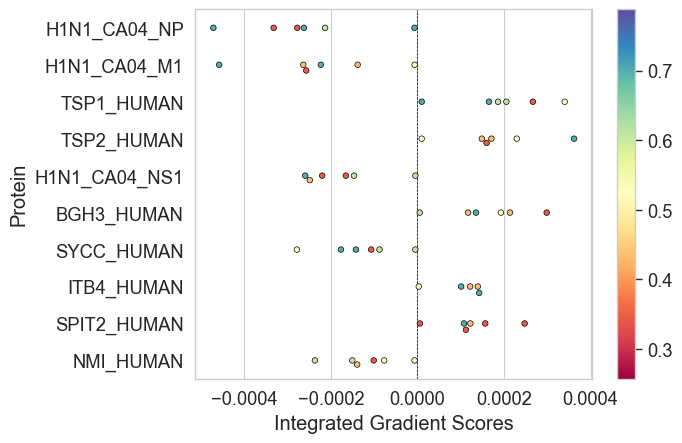

In [436]:
igrad_beeswarm_plot(pro_igrad_plot_df, ycol = "Protein", ylabel = "Protein")

In [441]:
# check that we aligned the columns correctly
assert((lipids_shap_out.iloc[:, 2:].abs().sum(axis=1) == lipids_shap_out.Lipid_Scores).all())
assert((proteins_shap_out.iloc[:, 2:].abs().sum(axis=1) == proteins_shap_out.Protein_Scores).all())
assert((metabolites_shap_out.iloc[:, 2:].abs().sum(axis=1) == metabolites_shap_out.Metabolite_Scores).all())

assert(np.isclose(lipids_igrad_out.iloc[:, 2:].abs().sum(axis=1), lipids_igrad_out.Lipid_Scores).all())
assert(np.isclose(proteins_igrad_out.iloc[:, 2:].abs().sum(axis=1), proteins_igrad_out.Protein_Scores).all())
assert(np.isclose(metabolites_igrad_out.iloc[:, 2:].abs().sum(axis=1), metabolites_igrad_out.Metabolite_Scores).all())

In [206]:
thetime = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

lipids_igrad_out.to_csv(f"./output/lipids_igrads_mlp_{thetime}.csv")
proteins_igrad_out.to_csv(f"./output/proteins_igrads_mlp_{thetime}.csv")
metabolites_igrad_out.to_csv(f"./output/metabolites_igrads_mlp_{thetime}.csv")

lipids_shap_out.to_csv(f"./output/lipids_shap_mlp_{thetime}.csv")
proteins_shap_out.to_csv(f"./output/proteins_shap_mlp_{thetime}.csv")
metabolites_shap_out.to_csv(f"./output/metabolites_shap_mlp_{thetime}.csv")


## Compare both to each other and ANOVA results

We compare the integrated gradient and shapley value results to the ANOVA via a hypergeometric distribution.  Essentially, we want to know, if we select the top $n_1$ biomolecules from integrated gradients, what is the probability that we would observe the amount of overlap with the top $n_2$ biomolecules from ANOVA by chance?  We can calculate this probability using the hypergeometric distribution.

The choice of $n_1$ and $n_2$ is a but subjective, however 10% of all biomolecules seems reasonable.

In [138]:
# significant biomolecules
pro_anova = pd.read_csv("./data/anova_results/pep/anova_results.csv")
lip_pos_anova = pd.read_csv("./data/anova_results/lip_pos/anova_results.csv")
metab_anova = pd.read_csv("./data/anova_results/metab/anova_results.csv")

# sort pro_anova by p-value columns
top_pro_anova = pro_anova.sort_values(by = ['P_value_A_Cal04_vs_Mock'], ascending = True)["Protein"]
top_lip_anova = lip_pos_anova.sort_values(by = ['P_value_A_Cal04_vs_Mock'], ascending = True)["Lipid"]
top_metab_anova = metab_anova.sort_values(by = ['P_value_A_Cal04_vs_Mock'], ascending = True)["Metabolite"]

In [147]:
overlap_sets(set(proteins_igrad['Proteins'][:285]), set(proteins_shap['Proteins'][:285]), M = proteins_shap.shape[0])

p(x) : 1.842505543139651e-152
p-value <= 192: 1.0
p-value >= 192: 1.8764509201701693e-152


(1.842505543139651e-152, 1.0, 1.8764509201701693e-152)

In [141]:
overlap_sets(set(top_pro_anova[:285]), set(proteins_shap['Proteins'][:285]), M = proteins_shap.shape[0])

p(x) : 3.153632744908483e-23
p-value <= 84: 1.0
p-value >= 84: 3.9402689125267226e-23


(3.153632744908483e-23, 1.0, 3.9402689125267226e-23)

In [142]:
# test all < alpha vs elbow cutoff
overlap_sets(set(top_pro_anova[:400]), set(proteins_igrad['Proteins'][:100]), M = proteins_shap.shape[0])

p(x) : 7.719404591132701e-38
p-value <= 69: 1.0
p-value >= 69: 8.214821879899422e-38


(7.719404591132701e-38, 1.0, 8.214821879899422e-38)

In [143]:
overlap_sets(set(top_lip_anova[:25]), set(lipids_shap['Lipids'][:25]), M = proteins_shap.shape[0])

p(x) : 0.0011530368196887707
p-value <= 3: 0.9999486976571028
p-value >= 3: 0.0012043391625859493


(0.0011530368196887707, 0.9999486976571028, 0.0012043391625859493)

In [144]:
overlap_sets(set(top_metab_anova[:13]), set(metabolites_shap['Metabolites'][:13]), M = proteins_shap.shape[0])

p(x) : 0.05630775063097171
p-value <= 1: 0.998546323319659
p-value >= 1: 0.05776142731131272


(0.05630775063097171, 0.998546323319659, 0.05776142731131272)